# Amazon Mattress Price 분석 : BSR Top 10 제품

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib.ticker import PercentFormatter
import numpy as np
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D

In [3]:
import os
import sys

import io
from io import BytesIO
import csv

import google.auth
from google.cloud import bigquery
#from google.cloud import bigquery_storage

In [4]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "../market-analysis-project-91130-5213911f50a5.json"

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [8]:
# get the data from BigQuery
sql = f"""
select * from dw.amz_bsr_matt_top10_price 
where bsr_date >= '2026-01-01'
"""

df_source = bqclient.query(sql).to_dataframe()

In [10]:
print(df_source)

       final_inch final_size          brand    bsr_date        asin  \
0            12.0       Full    PAYLESSHERE  2026-02-16  B0C3QVNJ4F   
1            12.0       Full    PAYLESSHERE  2026-02-12  B0C3QVNJ4F   
2            10.0       King  AMAZON BASICS  2026-01-29  B0B34DVGJH   
3            10.0       King  AMAZON BASICS  2026-02-03  B0B34DVGJH   
4            10.0       King  AMAZON BASICS  2026-02-04  B0B34DVGJH   
...           ...        ...            ...         ...         ...   
17474         8.0       Twin          ZINUS  2026-02-21  B0CKYZPPMJ   
17475         8.0       Twin          ZINUS  2026-02-14  B0CKYZPPMJ   
17476         8.0       Twin          ZINUS  2026-03-02  B0CKYZPPMJ   
17477         8.0       Twin          ZINUS  2026-02-15  B0CKYZPPMJ   
17478         8.0       Twin          ZINUS  2026-03-04  B0CKYZPPMJ   

      parent_asin     meta_brand      type  size          style  ...  \
0      B0D8PQM1CL    PayLessHere  MATTRESS  Full          12 IN  ...   
1  

In [12]:
df_source['bsr_date'].max()

'2026-03-22'

In [20]:
df = df_source.copy()

In [35]:
market_excl.mean()

202.14673635746095

In [31]:
# ═══════════════════════════════════════════════════════════
# 1.1 전체 브랜드별 평균 가격 비교
# ═══════════════════════════════════════════════════════════
print("=" * 70)
print("1. 브랜드별 평균 Buybox Price (전체)")
print("=" * 70)

# ── Step 1: ASIN별 평균가 & 등장횟수 집계 ──
asin_stats = (
    df.dropna(subset=['buybox_price'])
    .groupby(['brand_clean', 'asin'])['buybox_price']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'asin_avg', 'count': 'asin_n'})
    .reset_index()
)

# ── Step 2: 브랜드별 avg_price (ASIN당 1표) + wavg_price (등장횟수 가중) ──
brand_avg = (
    asin_stats.groupby('brand_clean')
    .agg(
        avg_price=('asin_avg', 'mean'),
        n=('asin_n', 'sum'),
        unique_asins=('asin', 'nunique'),
    )
    .sort_values('avg_price', ascending=False)
)

brand_wavg = (
    asin_stats.groupby('brand_clean')
    .apply(lambda g: np.average(g['asin_avg'], weights=g['asin_n']), include_groups=False)
    .rename('wavg_price')
)
brand_avg = brand_avg.join(brand_wavg)

# ── Step 3: 시장 평균 (이전 방식: row 기반, ZINUS 제외) ──
market_excl = df[df['brand_clean'] != TARGET]['buybox_price'].dropna()
market_avg = market_excl.mean()
market_med = market_excl.median()

zinus_avg = brand_avg.loc[TARGET, 'avg_price'] if TARGET in brand_avg.index else np.nan
zinus_wavg = brand_avg.loc[TARGET, 'wavg_price'] if TARGET in brand_avg.index else np.nan

# ── Step 4: 프리미엄 계산 (시장 평균 = row 기반) ──
brand_avg['premium_%'] = ((brand_avg['avg_price'] - market_avg) / market_avg * 100).round(1)
brand_avg['wavg_premium_%'] = ((brand_avg['wavg_price'] - market_avg) / market_avg * 100).round(1)

# 컬럼 순서 정리
brand_avg = brand_avg[['avg_price', 'wavg_price', 'n', 'unique_asins', 'premium_%', 'wavg_premium_%']]
print(brand_avg.round(2).to_string())

print(f"\n▶ 시장 평균(ZINUS 제외, row 기반): ${market_avg:.2f} | 중앙값: ${market_med:.2f}")
print(f"▶ ZINUS avg: ${zinus_avg:.2f} | wavg: ${zinus_wavg:.2f}")
print(f"▶ ZINUS 프리미엄: avg {(zinus_avg / market_avg - 1) * 100:+.1f}% | wavg {(zinus_wavg / market_avg - 1) * 100:+.1f}%")

1. 브랜드별 평균 Buybox Price (전체)
                     avg_price  wavg_price     n  unique_asins  premium_%  wavg_premium_%
brand_clean                                                                              
MLILY                   301.96      331.73  2016            39       49.4            64.1
FATHOM                  255.84      257.32   210            27       26.6            27.3
CRYREINA                227.36      243.05    89             7       12.5            20.2
BEST PRICE MATTRESS     217.46      219.95  1063            29        7.6             8.8
AMAZON BASICS           205.50      210.19    90            27        1.7             4.0
CH CHARME HOUSE         195.06      195.06    26            26       -3.5            -3.5
NOVILLA                 192.11      191.07  4046           117       -5.0            -5.5
ZINUS                   191.36      195.98  3520            66       -5.3            -3.0
NINARE                  187.00      187.00     3             3       -7

## 2026년 만

In [49]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib import rcParams

# ─── 설정 ───────────────────────────────────────────────
rcParams['font.family'] = 'DejaVu Sans'
rcParams['figure.dpi'] = 150
ZINUS_VARIANTS = ['ZINUS', 'Zinus', 'zinus']
TARGET = 'ZINUS'

# ─── 데이터 로드 ─────────────────────────────────────────
# TODO: 실제 파일 경로로 변경
# df = pd.read_csv('your_file.csv').copy()

# brand 통일 (Zinus/ZINUS/zinus → ZINUS)
df['brand_clean'] = df['brand'].apply(lambda x: TARGET if x in ZINUS_VARIANTS else x)

# 숫자 컬럼 정리
df['buybox_price'] = pd.to_numeric(df['buybox_price'], errors='coerce')
df['list_price'] = pd.to_numeric(df['list_price'], errors='coerce')
df['final_inch'] = pd.to_numeric(df['final_inch'], errors='coerce')

# ═══════════════════════════════════════════════════════════
# 1. 전체 브랜드별 평균 가격 비교 + unique ASIN 수
# ═══════════════════════════════════════════════════════════
print("=" * 70)
print("1. 브랜드별 평균 Buybox Price (전체)")
print("=" * 70)

brand_avg = (
    df.dropna(subset=['buybox_price'])
    .groupby('brand_clean')
    .agg(
        avg_price=('buybox_price', 'mean'),
        med_price=('buybox_price', 'median'),
        n=('buybox_price', 'count'),
        unique_asins=('asin', 'nunique'),          # ★ 추가
    )
    .sort_values('avg_price', ascending=False)
)

# 시장 평균 (ZINUS 제외)
market_excl = df[df['brand_clean'] != TARGET]['buybox_price'].dropna()
market_avg = market_excl.mean()
market_med = market_excl.median()

zinus_avg = brand_avg.loc[TARGET, 'avg_price'] if TARGET in brand_avg.index else np.nan
zinus_med = brand_avg.loc[TARGET, 'med_price'] if TARGET in brand_avg.index else np.nan

brand_avg['premium_vs_market_%'] = ((brand_avg['avg_price'] - market_avg) / market_avg * 100).round(1)
print(brand_avg.head(30).round(2).to_string())
print(f"\n▶ 시장 평균(ZINUS 제외): ${market_avg:.2f} | 중앙값: ${market_med:.2f}")
print(f"▶ ZINUS 평균: ${zinus_avg:.2f} | 중앙값: ${zinus_med:.2f}")
print(f"▶ ZINUS 프리미엄: {(zinus_avg / market_avg - 1) * 100:+.1f}% (평균 대비)")

# ═══════════════════════════════════════════════════════════
# 2. Inch × Size 세그먼트별 가격 비교 + unique ASIN 수
# ═══════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("2. Inch × Size 세그먼트별 ZINUS vs 경쟁사 가격 비교")
print("=" * 70)

# ★ 수정: unique ASIN도 함께 집계
segments = (
    df.dropna(subset=['buybox_price'])
    .groupby(['final_inch', 'final_size', 'brand_clean'])
    .agg(
        avg_price=('buybox_price', 'mean'),
        n=('buybox_price', 'count'),
        unique_asins=('asin', 'nunique'),           # ★ 추가
    )
    .reset_index()
)
segments.columns = ['inch', 'size', 'brand', 'avg_price', 'n', 'unique_asins']
segments = segments[segments['n'] > 0]


def calc_premium(grp):
    z = grp[grp['brand'] == TARGET]
    others = grp[grp['brand'] != TARGET]
    if z.empty or others.empty:
        return None
    z_price = z['avg_price'].values[0]
    mkt_price = others['avg_price'].mean()
    mkt_wavg = np.average(others['avg_price'], weights=others['n'])
    return pd.Series({
        'zinus_price': z_price,
        'competitor_avg': mkt_price,
        'competitor_wavg': mkt_wavg,
        'premium_%': (z_price / mkt_wavg - 1) * 100,
        'premium_$': z_price - mkt_wavg,
        'zinus_n': z['n'].values[0],
        'zinus_asins': z['unique_asins'].values[0],         # ★ 추가
        'comp_brands': len(others),
        'comp_asins': others['unique_asins'].sum(),          # ★ 추가
    })


seg_premium = (
    segments.groupby(['inch', 'size'])
    .apply(calc_premium, include_groups=False)
    .dropna()
    .reset_index()
)
seg_premium = seg_premium.sort_values(['inch', 'size'])

# 정수로 표시할 컬럼
int_cols = ['zinus_n', 'zinus_asins', 'comp_brands', 'comp_asins']
for col in int_cols:
    seg_premium[col] = seg_premium[col].astype(int)

print(seg_premium.round(2).to_string(index=False))

if not seg_premium.empty:
    worst = seg_premium.loc[seg_premium['premium_%'].idxmax()]
    best = seg_premium.loc[seg_premium['premium_%'].idxmin()]
    print(f"\n▶ 가장 높은 프리미엄: {worst['inch']:.0f}\" {worst['size']} → {worst['premium_%']:+.1f}%")
    print(f"▶ 가장 낮은 프리미엄(혹은 할인): {best['inch']:.0f}\" {best['size']} → {best['premium_%']:+.1f}%")

# ═══════════════════════════════════════════════════════════
# 3. Inch별 요약
# ═══════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("3. Inch별 ZINUS 프리미엄 요약")
print("=" * 70)

df_valid = df.dropna(subset=['buybox_price'])


def inch_premium(grp):
    z = grp[grp['brand_clean'] == TARGET]['buybox_price']
    o = grp[grp['brand_clean'] != TARGET]['buybox_price']
    if z.empty or o.empty:
        return None
    return pd.Series({
        'zinus_avg': z.mean(),
        'comp_avg': o.mean(),
        'premium_%': (z.mean() / o.mean() - 1) * 100,
        'premium_$': z.mean() - o.mean(),
    })


inch_summary = (
    df_valid.groupby('final_inch')
    .apply(inch_premium, include_groups=False)
    .dropna()
)
print(inch_summary.round(2).to_string())

# ═══════════════════════════════════════════════════════════
# 4. Size별 요약
# ═══════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("4. Size별 ZINUS 프리미엄 요약")
print("=" * 70)

size_order = ['Twin', 'Twin XL', 'Full', 'Short Queen', 'Queen', 'King', 'Cal King']


def size_premium(grp):
    z = grp[grp['brand_clean'] == TARGET]['buybox_price']
    o = grp[grp['brand_clean'] != TARGET]['buybox_price']
    if z.empty or o.empty:
        return None
    return pd.Series({
        'zinus_avg': z.mean(),
        'comp_avg': o.mean(),
        'premium_%': (z.mean() / o.mean() - 1) * 100,
        'premium_$': z.mean() - o.mean(),
    })


size_summary = (
    df_valid.groupby('final_size')
    .apply(size_premium, include_groups=False)
    .dropna()
)
size_summary = size_summary.reindex([s for s in size_order if s in size_summary.index])
print(size_summary.round(2).to_string())

# ═══════════════════════════════════════════════════════════
# 5. 시각화 (4패널)
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('ZINUS Price Premium Analysis vs Competitors (Amazon Mattress BSR Top 10)',
             fontsize=14, fontweight='bold', y=0.98)

# --- (a) 브랜드별 평균 가격 ---
ax = axes[0, 0]
top_brands = brand_avg.nlargest(15, 'avg_price')
colors = ['#e74c3c' if b == TARGET else '#95a5a6' for b in top_brands.index]
ax.barh(top_brands.index[::-1], top_brands['avg_price'][::-1], color=colors[::-1])
ax.axvline(market_avg, color='#2c3e50', ls='--', lw=1.5,
           label=f'Market avg (excl ZINUS): ${market_avg:.0f}')
ax.set_xlabel('Avg Buybox Price ($)')
ax.set_title('(a) Brand Avg Price (Top 15)')
ax.legend(fontsize=8)

# --- (b) Inch별 프리미엄 ---
ax = axes[0, 1]
if not inch_summary.empty:
    x = inch_summary.index.astype(str)
    w = 0.35
    idx = np.arange(len(x))
    ax.bar(idx - w / 2, inch_summary['zinus_avg'], w, label='ZINUS', color='#e74c3c')
    ax.bar(idx + w / 2, inch_summary['comp_avg'], w, label='Competitors', color='#95a5a6')
    for i, (_, row) in enumerate(inch_summary.iterrows()):
        ax.annotate(f"{row['premium_%']:+.1f}%",
                    xy=(i, max(row['zinus_avg'], row['comp_avg']) + 5),
                    ha='center', fontsize=8, fontweight='bold',
                    color='#e74c3c' if row['premium_%'] > 0 else '#27ae60')
    ax.set_xticks(idx)
    ax.set_xticklabels([f'{v}"' for v in x])
    ax.set_ylabel('Avg Buybox Price ($)')
    ax.set_title('(b) ZINUS vs Competitors by Inch')
    ax.legend(fontsize=8)

# --- (c) Size별 프리미엄 ---
ax = axes[1, 0]
if not size_summary.empty:
    x = size_summary.index
    w = 0.35
    idx = np.arange(len(x))
    ax.bar(idx - w / 2, size_summary['zinus_avg'], w, label='ZINUS', color='#e74c3c')
    ax.bar(idx + w / 2, size_summary['comp_avg'], w, label='Competitors', color='#95a5a6')
    for i, (_, row) in enumerate(size_summary.iterrows()):
        ax.annotate(f"{row['premium_%']:+.1f}%",
                    xy=(i, max(row['zinus_avg'], row['comp_avg']) + 5),
                    ha='center', fontsize=8, fontweight='bold',
                    color='#e74c3c' if row['premium_%'] > 0 else '#27ae60')
    ax.set_xticks(idx)
    ax.set_xticklabels(x, rotation=30, ha='right')
    ax.set_ylabel('Avg Buybox Price ($)')
    ax.set_title('(c) ZINUS vs Competitors by Size')
    ax.legend(fontsize=8)

# --- (d) Inch×Size 히트맵 (프리미엄 %) ---
ax = axes[1, 1]
if not seg_premium.empty:
    pivot = seg_premium.pivot_table(index='inch', columns='size', values='premium_%')
    col_order = [s for s in size_order if s in pivot.columns]
    pivot = pivot[col_order]

    im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto',
                   vmin=-30, vmax=30)
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=30, ha='right')
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels([f'{v:.0f}"' for v in pivot.index])
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.iloc[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:+.1f}%', ha='center', va='center',
                        fontsize=7, fontweight='bold',
                        color='white' if abs(val) > 20 else 'black')
    plt.colorbar(im, ax=ax, label='Premium %', shrink=0.8)
    ax.set_title('(d) ZINUS Premium % Heatmap (Inch × Size)')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('zinus_price_premium.png', bbox_inches='tight', dpi=150)
plt.close()
print("\n✅ 4패널 차트 저장 완료: zinus_price_premium.png")

# ═══════════════════════════════════════════════════════════
# 6. 상세 히트맵 (별도 차트)
# ═══════════════════════════════════════════════════════════

if not seg_premium.empty:
    pivot_pct = seg_premium.pivot_table(index='inch', columns='size', values='premium_%')
    pivot_dol = seg_premium.pivot_table(index='inch', columns='size', values='premium_$')
    pivot_zn  = seg_premium.pivot_table(index='inch', columns='size', values='zinus_n')
    pivot_za  = seg_premium.pivot_table(index='inch', columns='size', values='zinus_asins')
    pivot_cb  = seg_premium.pivot_table(index='inch', columns='size', values='comp_brands')
    pivot_ca  = seg_premium.pivot_table(index='inch', columns='size', values='comp_asins')

    col_order = [s for s in size_order if s in pivot_pct.columns]
    pivot_pct = pivot_pct[col_order]
    pivot_dol = pivot_dol.reindex(columns=col_order)
    pivot_zn  = pivot_zn.reindex(columns=col_order)
    pivot_za  = pivot_za.reindex(columns=col_order)
    pivot_cb  = pivot_cb.reindex(columns=col_order)
    pivot_ca  = pivot_ca.reindex(columns=col_order)

    fig2, ax2 = plt.subplots(figsize=(15, 9))

    cmap = mcolors.LinearSegmentedColormap.from_list(
        'premium', ['#27ae60', '#2ecc71', '#ffffff', '#e74c3c', '#c0392b']
    )
    vmax = max(abs(pivot_pct.min().min()), abs(pivot_pct.max().max()), 30)

    im2 = ax2.imshow(pivot_pct.values, cmap=cmap, aspect='auto',
                     vmin=-vmax, vmax=vmax)

    ax2.set_xticks(np.arange(len(pivot_pct.columns)))
    ax2.set_xticklabels(pivot_pct.columns, fontsize=11, fontweight='bold')
    ax2.set_yticks(np.arange(len(pivot_pct.index)))
    ax2.set_yticklabels([f'{v:.0f}"' for v in pivot_pct.index], fontsize=11, fontweight='bold')

    for i in range(len(pivot_pct.index)):
        for j in range(len(pivot_pct.columns)):
            pct = pivot_pct.iloc[i, j]
            if np.isnan(pct):
                ax2.text(j, i, 'N/A', ha='center', va='center',
                         fontsize=9, color='#bdc3c7', style='italic')
                continue

            dol = pivot_dol.iloc[i, j]
            za  = pivot_za.iloc[i, j]
            ca  = pivot_ca.iloc[i, j]
            cb  = pivot_cb.iloc[i, j]
            txt_color = 'white' if abs(pct) > 25 else 'black'

            # 1행: 프리미엄 %
            ax2.text(j, i - 0.25, f'{pct:+.1f}%',
                     ha='center', va='center', fontsize=11, fontweight='bold',
                     color=txt_color)
            # 2행: 프리미엄 $ 차이
            ax2.text(j, i + 0.0, f'(${dol:+.0f})',
                     ha='center', va='center', fontsize=9,
                     color=txt_color, alpha=0.85)
            # 3행: ZINUS ASIN수 vs 경쟁사 ASIN수 (브랜드수)
            ax2.text(j, i + 0.25, f'Z:{za:.0f}asin / C:{ca:.0f}asin({cb:.0f}br)',
                     ha='center', va='center', fontsize=6.5,
                     color=txt_color, alpha=0.6)

    for i in range(len(pivot_pct.index) + 1):
        ax2.axhline(i - 0.5, color='white', lw=2)
    for j in range(len(pivot_pct.columns) + 1):
        ax2.axvline(j - 0.5, color='white', lw=2)

    cbar = plt.colorbar(im2, ax=ax2, shrink=0.8, pad=0.02)
    cbar.set_label('ZINUS Premium vs Competitors (%)', fontsize=10)

    ax2.set_title('ZINUS Price Premium Heatmap by Inch x Size\n'
                  '(vs Competitor Weighted Avg Buybox Price)',
                  fontsize=14, fontweight='bold', pad=15)
    ax2.set_xlabel('Size', fontsize=12, labelpad=10)
    ax2.set_ylabel('Thickness (Inch)', fontsize=12, labelpad=10)

    fig2.text(0.02, 0.02,
              'Red = ZINUS more expensive  |  Green = ZINUS cheaper  |  '
              'Z = ZINUS unique ASINs  |  C = Competitor unique ASINs (brands)',
              fontsize=8, color='#7f8c8d', style='italic')

    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig('zinus_premium_heatmap.png', bbox_inches='tight', dpi=150)
    plt.close()
    print("✅ 상세 히트맵 저장 완료: zinus_premium_heatmap.png")

# ═══════════════════════════════════════════════════════════
# 7. 심각도 종합 평가
# ═══════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("심각도 종합 평가")
print("=" * 70)

overall_prem = (zinus_avg / market_avg - 1) * 100
print(f"  전체 프리미엄: {overall_prem:+.1f}%")

if not seg_premium.empty:
    prem_positive = seg_premium[seg_premium['premium_%'] > 0]
    print(f"  ZINUS가 더 비싼 세그먼트: {len(prem_positive)} / {len(seg_premium)} ({len(prem_positive) / len(seg_premium) * 100:.0f}%)")
    print(f"  프리미엄 평균: {seg_premium['premium_%'].mean():+.1f}%")
    print(f"  프리미엄 최대: {seg_premium['premium_%'].max():+.1f}%")
    print(f"  프리미엄 최소: {seg_premium['premium_%'].min():+.1f}%")

seg_prem_avg = seg_premium['premium_%'].mean() if not seg_premium.empty else 0
if seg_prem_avg > 20:
    severity = "매우 심각 - 세그먼트 평균 20%+ 고가. 가격 경쟁력 재검토 필요"
elif seg_prem_avg > 10:
    severity = "주의 - 세그먼트 평균 10~20% 고가. 선별적 조정 권장"
elif seg_prem_avg > 0:
    severity = "경고 - 세그먼트 평균 소폭 프리미엄. 동일 스펙 기준 경쟁사보다 비쌈"
else:
    severity = "경쟁적 - 세그먼트 평균 기준 시장 이하 가격"

print(f"\n  심각도 판정: {severity}")
print(f"    (전체 평균 기준: {overall_prem:+.1f}% | 세그먼트 평균 기준: {seg_prem_avg:+.1f}%)")

1. 브랜드별 평균 Buybox Price (전체)
                     avg_price  med_price     n  unique_asins  premium_vs_market_%
brand_clean                                                                       
MLILY                   331.73     329.00  2016            39                 64.1
FATHOM                  257.32     259.99   210            27                 27.3
CRYREINA                243.05     227.99    89             7                 20.2
BEST PRICE MATTRESS     219.95     206.66  1063            29                  8.8
AMAZON BASICS           210.19     192.28    90            27                  4.0
ZINUS                   195.98     188.15  3520            66                 -3.0
CH CHARME HOUSE         195.06     186.08    26            26                 -3.5
NOVILLA                 191.07     176.99  4046           117                 -5.5
NINARE                  187.00     177.00     3             3                 -7.5
NAPQUEEN                184.24     170.44    15           

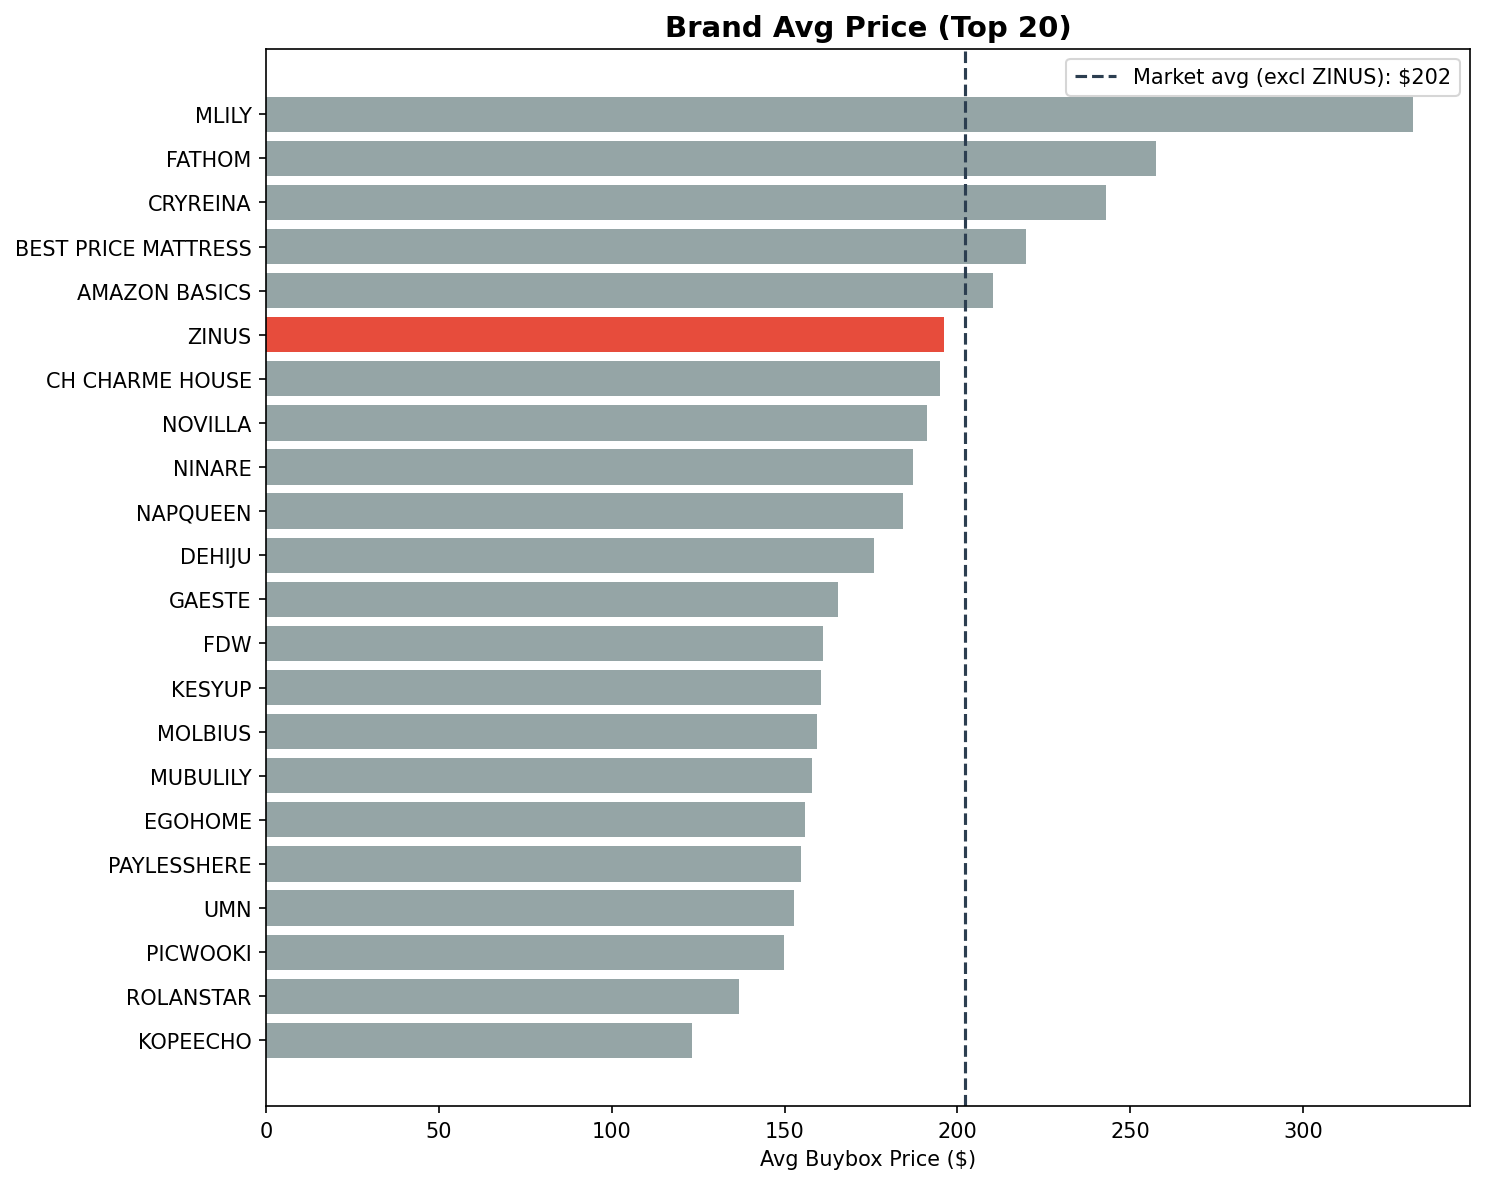

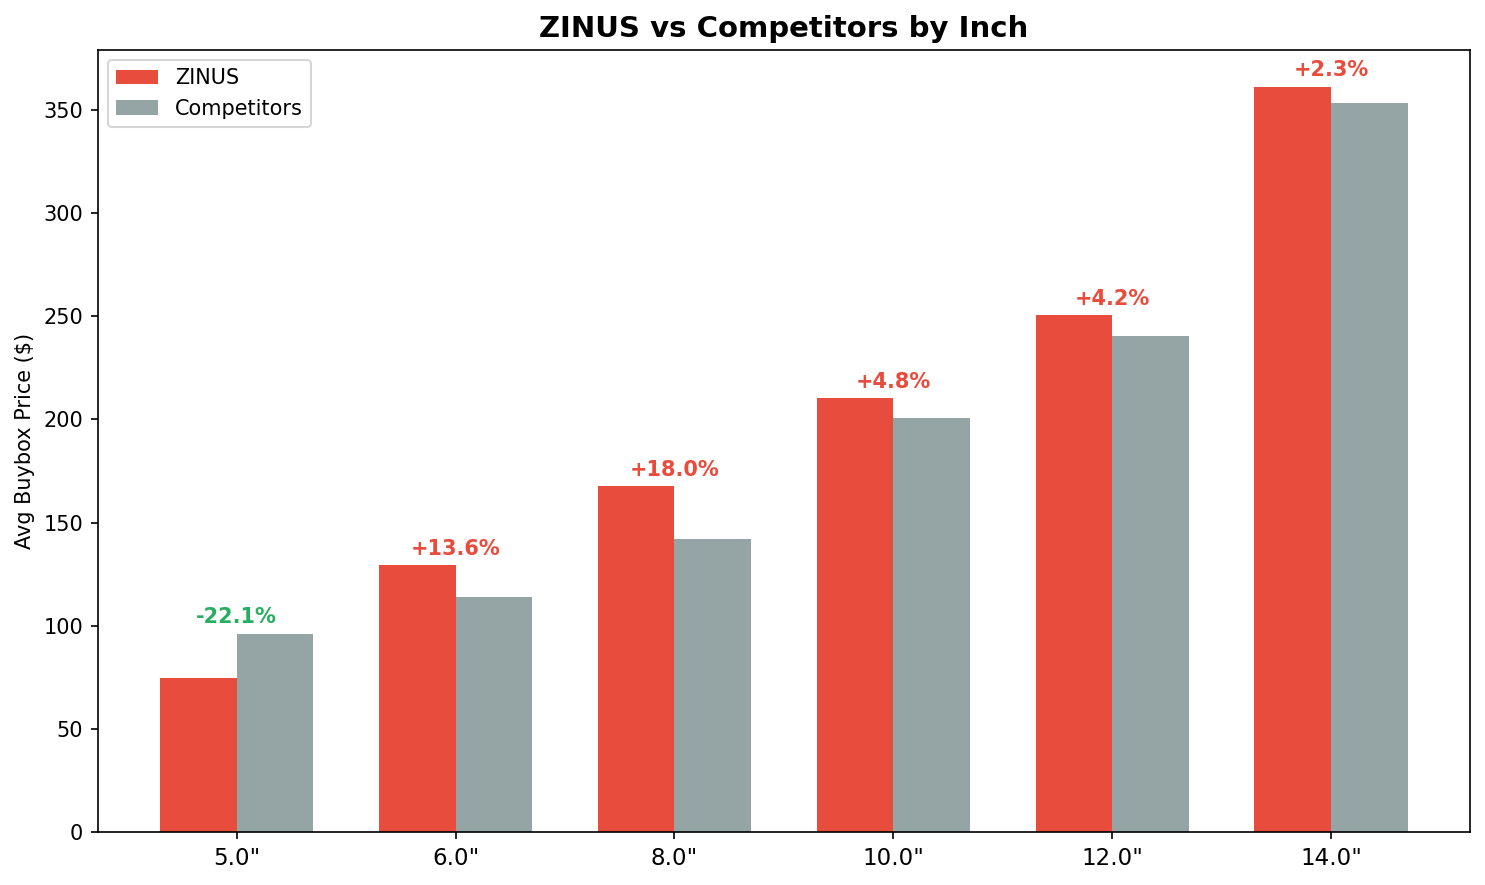

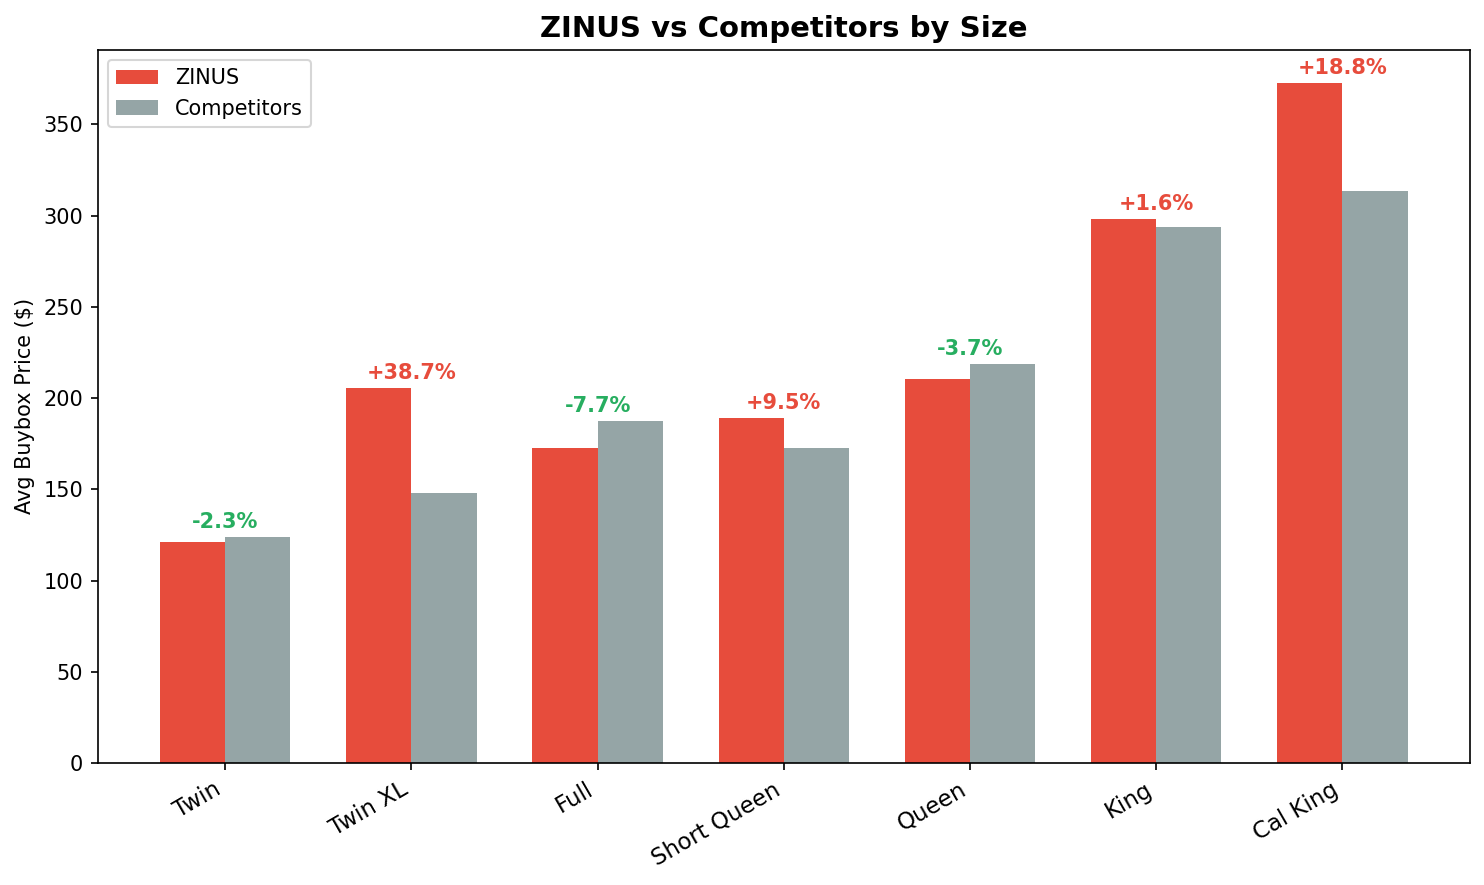

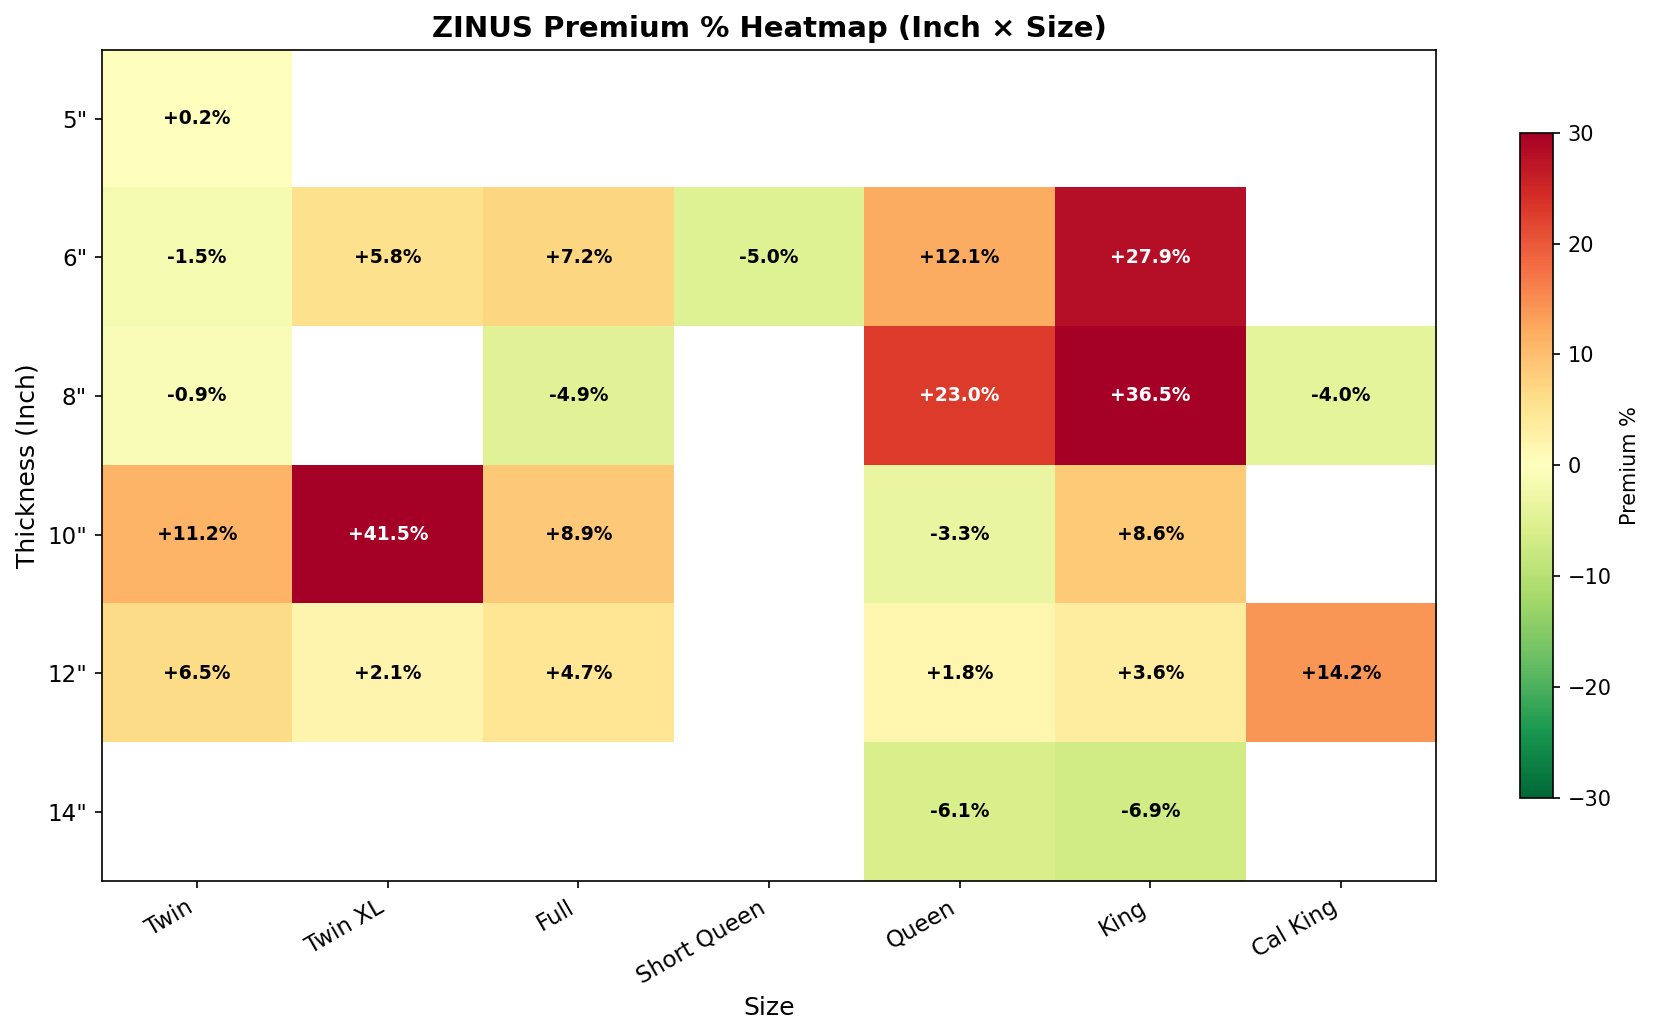

In [45]:
# ═══════════════════════════════════════════════════════════
# 5. 시각화 (개별 차트 4개)
# ═══════════════════════════════════════════════════════════

# --- (a) 브랜드별 평균 가격 ---
fig1, ax = plt.subplots(figsize=(10, 8))
top_brands = brand_avg.nlargest(30, 'avg_price')
colors = ['#e74c3c' if b == TARGET else '#95a5a6' for b in top_brands.index]
ax.barh(top_brands.index[::-1], top_brands['avg_price'][::-1], color=colors[::-1])
ax.axvline(market_avg, color='#2c3e50', ls='--', lw=1.5,
           label=f'Market avg (excl ZINUS): ${market_avg:.0f}')
ax.set_xlabel('Avg Buybox Price ($)')
ax.set_title('Brand Avg Price (Top 20)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()
plt.close()

# --- (b) Inch별 프리미엄 ---
if not inch_summary.empty:
    fig2, ax = plt.subplots(figsize=(10, 6))
    x = inch_summary.index.astype(str)
    w = 0.35
    idx = np.arange(len(x))
    ax.bar(idx - w / 2, inch_summary['zinus_avg'], w, label='ZINUS', color='#e74c3c')
    ax.bar(idx + w / 2, inch_summary['comp_avg'], w, label='Competitors', color='#95a5a6')
    for i, (_, row) in enumerate(inch_summary.iterrows()):
        ax.annotate(f"{row['premium_%']:+.1f}%",
                    xy=(i, max(row['zinus_avg'], row['comp_avg']) + 5),
                    ha='center', fontsize=10, fontweight='bold',
                    color='#e74c3c' if row['premium_%'] > 0 else '#27ae60')
    ax.set_xticks(idx)
    ax.set_xticklabels([f'{v}"' for v in x], fontsize=11)
    ax.set_ylabel('Avg Buybox Price ($)')
    ax.set_title('ZINUS vs Competitors by Inch', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()
    plt.close()

# --- (c) Size별 프리미엄 ---
if not size_summary.empty:
    fig3, ax = plt.subplots(figsize=(10, 6))
    x = size_summary.index
    w = 0.35
    idx = np.arange(len(x))
    ax.bar(idx - w / 2, size_summary['zinus_avg'], w, label='ZINUS', color='#e74c3c')
    ax.bar(idx + w / 2, size_summary['comp_avg'], w, label='Competitors', color='#95a5a6')
    for i, (_, row) in enumerate(size_summary.iterrows()):
        ax.annotate(f"{row['premium_%']:+.1f}%",
                    xy=(i, max(row['zinus_avg'], row['comp_avg']) + 5),
                    ha='center', fontsize=10, fontweight='bold',
                    color='#e74c3c' if row['premium_%'] > 0 else '#27ae60')
    ax.set_xticks(idx)
    ax.set_xticklabels(x, rotation=30, ha='right', fontsize=11)
    ax.set_ylabel('Avg Buybox Price ($)')
    ax.set_title('ZINUS vs Competitors by Size', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()
    plt.close()

# --- (d) Inch×Size 히트맵 (프리미엄 %) ---
if not seg_premium.empty:
    fig4, ax = plt.subplots(figsize=(12, 7))
    pivot = seg_premium.pivot_table(index='inch', columns='size', values='premium_%')
    col_order = [s for s in size_order if s in pivot.columns]
    pivot = pivot[col_order]

    im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto',
                   vmin=-30, vmax=30)
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=30, ha='right', fontsize=11)
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels([f'{v:.0f}"' for v in pivot.index], fontsize=11)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.iloc[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:+.1f}%', ha='center', va='center',
                        fontsize=9, fontweight='bold',
                        color='white' if abs(val) > 20 else 'black')
    plt.colorbar(im, ax=ax, label='Premium %', shrink=0.8)
    ax.set_title('ZINUS Premium % Heatmap (Inch × Size)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Size', fontsize=12)
    ax.set_ylabel('Thickness (Inch)', fontsize=12)
    plt.tight_layout()
    plt.show()
    plt.close()

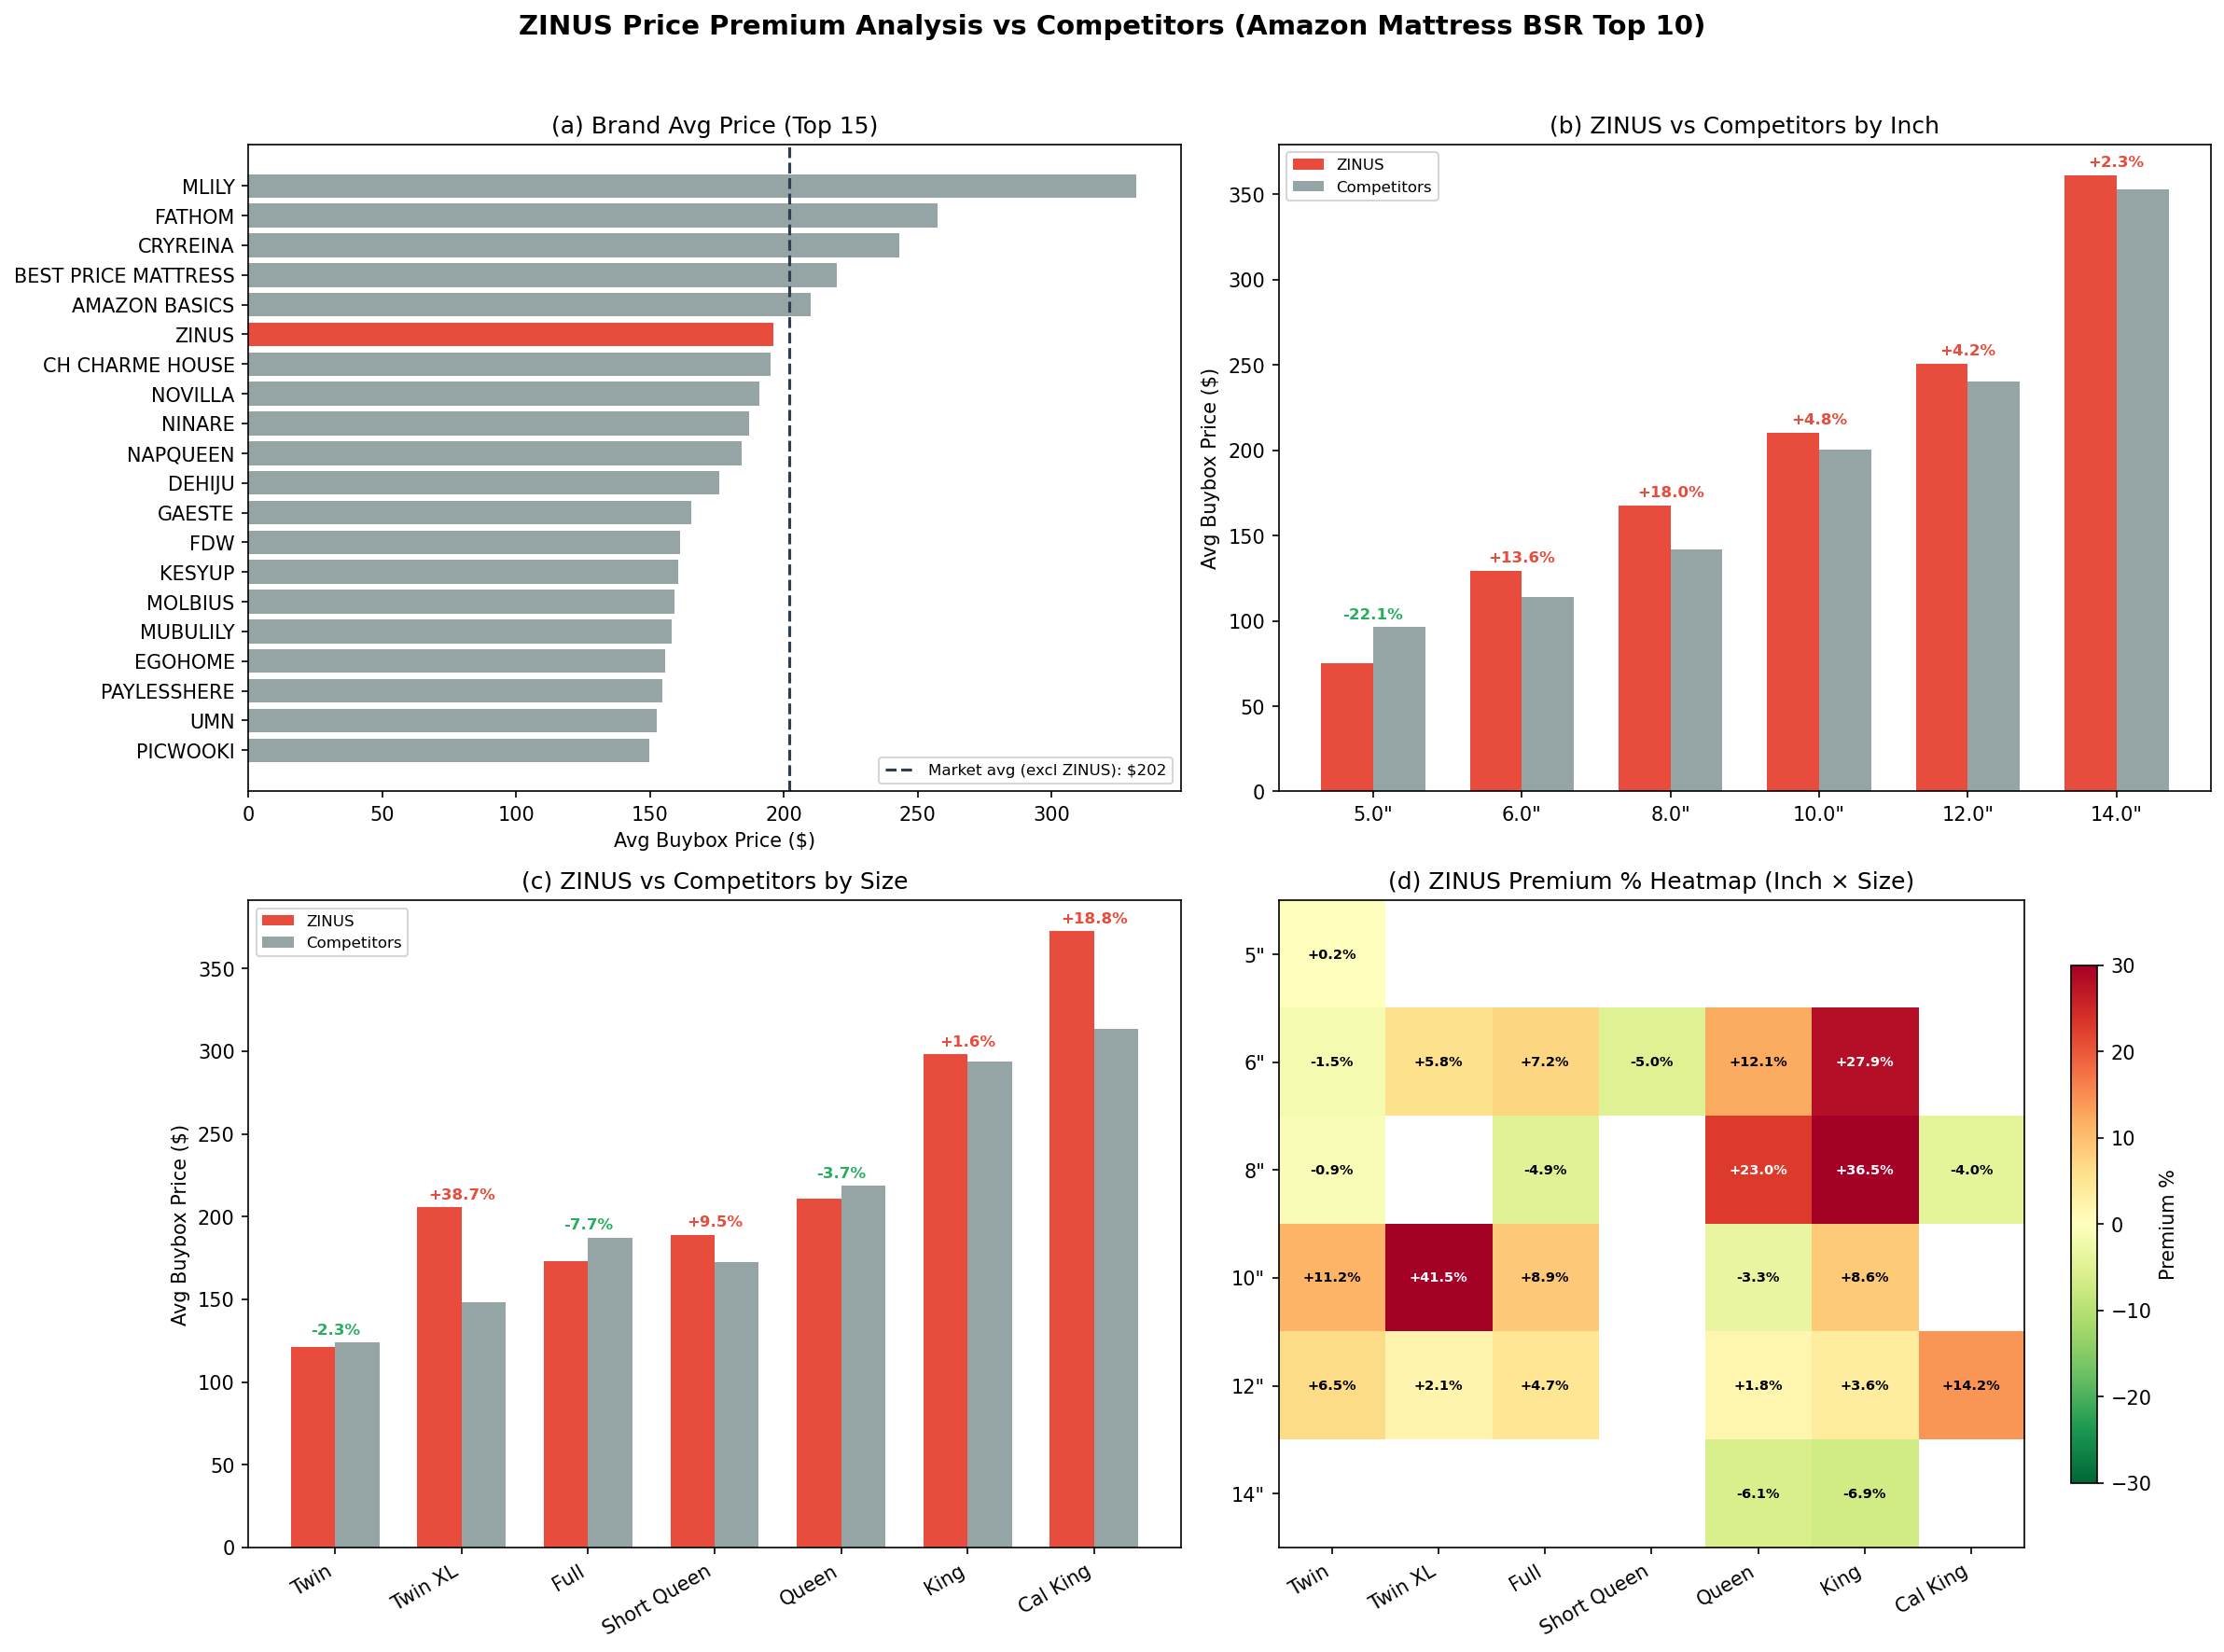

In [39]:

# ═══════════════════════════════════════════════════════════
# 5. 시각화
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('ZINUS Price Premium Analysis vs Competitors (Amazon Mattress BSR Top 10)',
             fontsize=14, fontweight='bold', y=0.98)

# --- (a) 브랜드별 평균 가격 ---
ax = axes[0, 0]
top_brands = brand_avg.nlargest(20, 'avg_price')
colors = ['#e74c3c' if b == TARGET else '#95a5a6' for b in top_brands.index]
bars = ax.barh(top_brands.index[::-1], top_brands['avg_price'][::-1], color=colors[::-1])
ax.axvline(market_avg, color='#2c3e50', ls='--', lw=1.5, label=f'Market avg (excl ZINUS): ${market_avg:.0f}')
ax.set_xlabel('Avg Buybox Price ($)')
ax.set_title('(a) Brand Avg Price (Top 15)')
ax.legend(fontsize=8)

# --- (b) Inch별 프리미엄 ---
ax = axes[0, 1]
if not inch_summary.empty:
    x = inch_summary.index.astype(str)
    w = 0.35
    idx = np.arange(len(x))
    ax.bar(idx - w/2, inch_summary['zinus_avg'], w, label='ZINUS', color='#e74c3c')
    ax.bar(idx + w/2, inch_summary['comp_avg'], w, label='Competitors', color='#95a5a6')
    # 프리미엄 % 표시
    for i, (_, row) in enumerate(inch_summary.iterrows()):
        ax.annotate(f"{row['premium_%']:+.1f}%",
                    xy=(i, max(row['zinus_avg'], row['comp_avg']) + 5),
                    ha='center', fontsize=8, fontweight='bold',
                    color='#e74c3c' if row['premium_%'] > 0 else '#27ae60')
    ax.set_xticks(idx)
    ax.set_xticklabels([f'{v}"' for v in x])
    ax.set_ylabel('Avg Buybox Price ($)')
    ax.set_title('(b) ZINUS vs Competitors by Inch')
    ax.legend(fontsize=8)

# --- (c) Size별 프리미엄 ---
ax = axes[1, 0]
if not size_summary.empty:
    x = size_summary.index
    w = 0.35
    idx = np.arange(len(x))
    ax.bar(idx - w/2, size_summary['zinus_avg'], w, label='ZINUS', color='#e74c3c')
    ax.bar(idx + w/2, size_summary['comp_avg'], w, label='Competitors', color='#95a5a6')
    for i, (_, row) in enumerate(size_summary.iterrows()):
        ax.annotate(f"{row['premium_%']:+.1f}%",
                    xy=(i, max(row['zinus_avg'], row['comp_avg']) + 5),
                    ha='center', fontsize=8, fontweight='bold',
                    color='#e74c3c' if row['premium_%'] > 0 else '#27ae60')
    ax.set_xticks(idx)
    ax.set_xticklabels(x, rotation=30, ha='right')
    ax.set_ylabel('Avg Buybox Price ($)')
    ax.set_title('(c) ZINUS vs Competitors by Size')
    ax.legend(fontsize=8)

# --- (d) Inch×Size 히트맵 (프리미엄 %) ---
ax = axes[1, 1]
if not seg_premium.empty:
    pivot = seg_premium.pivot_table(index='inch', columns='size', values='premium_%')
    # 순서 정렬
    col_order = [s for s in size_order if s in pivot.columns]
    pivot = pivot[col_order]
    
    im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto',
                   vmin=-30, vmax=30)
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=30, ha='right')
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels([f'{v:.0f}"' for v in pivot.index])
    # 셀 값 표시
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.iloc[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:+.1f}%', ha='center', va='center',
                        fontsize=7, fontweight='bold',
                        color='white' if abs(val) > 20 else 'black')
    plt.colorbar(im, ax=ax, label='Premium %', shrink=0.8)
    ax.set_title('(d) ZINUS Premium % Heatmap (Inch × Size)')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
#plt.savefig('/home/claude/zinus_price_premium.png', bbox_inches='tight', dpi=150)
plt.close()
#print("\n✅ 차트 저장 완료: zinus_price_premium.png")


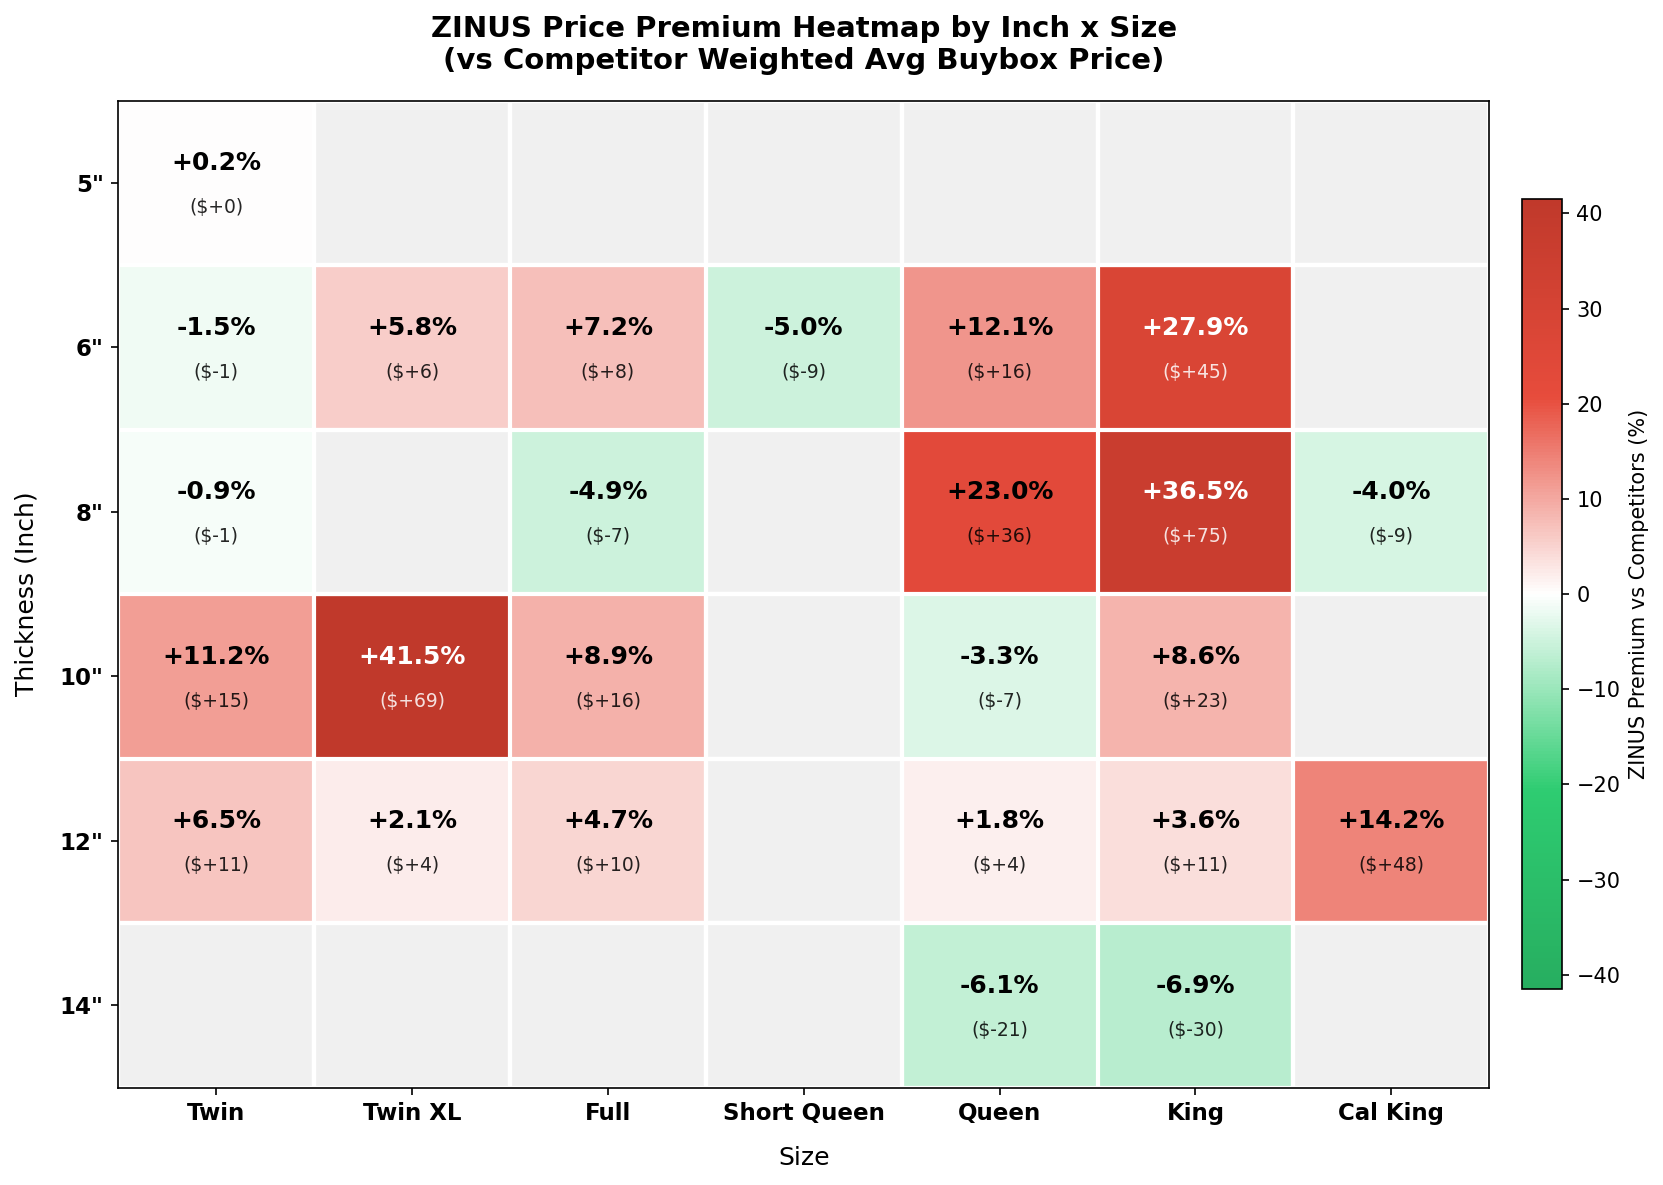

✅ 상세 히트맵 저장 완료: zinus_premium_heatmap.png


In [53]:
# ═══════════════════════════════════════════════════════════
# 6. 상세 히트맵 (별도 차트)
# ═══════════════════════════════════════════════════════════

if not seg_premium.empty:
    pivot_pct = seg_premium.pivot_table(index='inch', columns='size', values='premium_%')
    pivot_dol = seg_premium.pivot_table(index='inch', columns='size', values='premium_$')

    col_order = [s for s in size_order if s in pivot_pct.columns]
    pivot_pct = pivot_pct[col_order]
    pivot_dol = pivot_dol.reindex(columns=col_order)

    fig2, ax2 = plt.subplots(figsize=(12, 8))

    cmap = mcolors.LinearSegmentedColormap.from_list(
        'premium', ['#27ae60', '#2ecc71', '#ffffff', '#e74c3c', '#c0392b']
    )
    vmax = max(abs(pivot_pct.min().min()), abs(pivot_pct.max().max()), 30)

    im2 = ax2.imshow(pivot_pct.values, cmap=cmap, aspect='auto',
                     vmin=-vmax, vmax=vmax)

    ax2.set_xticks(np.arange(len(pivot_pct.columns)))
    ax2.set_xticklabels(pivot_pct.columns, fontsize=11, fontweight='bold')
    ax2.set_yticks(np.arange(len(pivot_pct.index)))
    ax2.set_yticklabels([f'{v:.0f}"' for v in pivot_pct.index], fontsize=11, fontweight='bold')

    for i in range(len(pivot_pct.index)):
        for j in range(len(pivot_pct.columns)):
            pct = pivot_pct.iloc[i, j]

            # N/A → 회색 빈칸
            if np.isnan(pct):
                ax2.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                             facecolor='#f0f0f0', edgecolor='white', lw=2))
                continue

            dol = pivot_dol.iloc[i, j]
            txt_color = 'white' if abs(pct) > 25 else 'black'

            # 1행: 프리미엄 %
            ax2.text(j, i - 0.12, f'{pct:+.1f}%',
                     ha='center', va='center', fontsize=12, fontweight='bold',
                     color=txt_color)
            # 2행: 프리미엄 $ 차이
            ax2.text(j, i + 0.15, f'(${dol:+.0f})',
                     ha='center', va='center', fontsize=9,
                     color=txt_color, alpha=0.85)

    for i in range(len(pivot_pct.index) + 1):
        ax2.axhline(i - 0.5, color='white', lw=2)
    for j in range(len(pivot_pct.columns) + 1):
        ax2.axvline(j - 0.5, color='white', lw=2)

    cbar = plt.colorbar(im2, ax=ax2, shrink=0.8, pad=0.02)
    cbar.set_label('ZINUS Premium vs Competitors (%)', fontsize=10)

    ax2.set_title('ZINUS Price Premium Heatmap by Inch x Size\n'
                  '(vs Competitor Weighted Avg Buybox Price)',
                  fontsize=14, fontweight='bold', pad=15)
    ax2.set_xlabel('Size', fontsize=12, labelpad=10)
    ax2.set_ylabel('Thickness (Inch)', fontsize=12, labelpad=10)

    plt.tight_layout()
    plt.savefig('zinus_premium_heatmap.png', bbox_inches='tight', dpi=150)
    plt.show()
    plt.close()
    print("✅ 상세 히트맵 저장 완료: zinus_premium_heatmap.png")

시장 규모 x ZINUS 프리미엄 결합 분석 (Risk Score)
 inch        size  sales_M  share_%  premium_%  premium_$  zinus_n  zinus_asins  comp_asins  risk_score
 10.0        Full    14.50      4.3       8.88      16.41      193            4          30        1.29
 12.0        King    31.78      9.4       3.65      10.95      193            4          28        1.16
 12.0        Full    24.41      7.3       4.74      10.37      192            4          30        1.16
 10.0        Twin     9.25      2.7      11.20      15.06      186            4          22        1.04
 12.0       Queen    56.90     16.9       1.77       4.26      192            4          29        1.01
  8.0       Queen     4.40      1.3      22.95      36.22      193            4          15        1.01
 10.0     Twin XL     1.46      0.4      41.48      68.94       65            1          11        0.61
  6.0       Queen     4.21      1.3      12.11      15.90      139            2           9        0.51
  6.0        Full     6.53

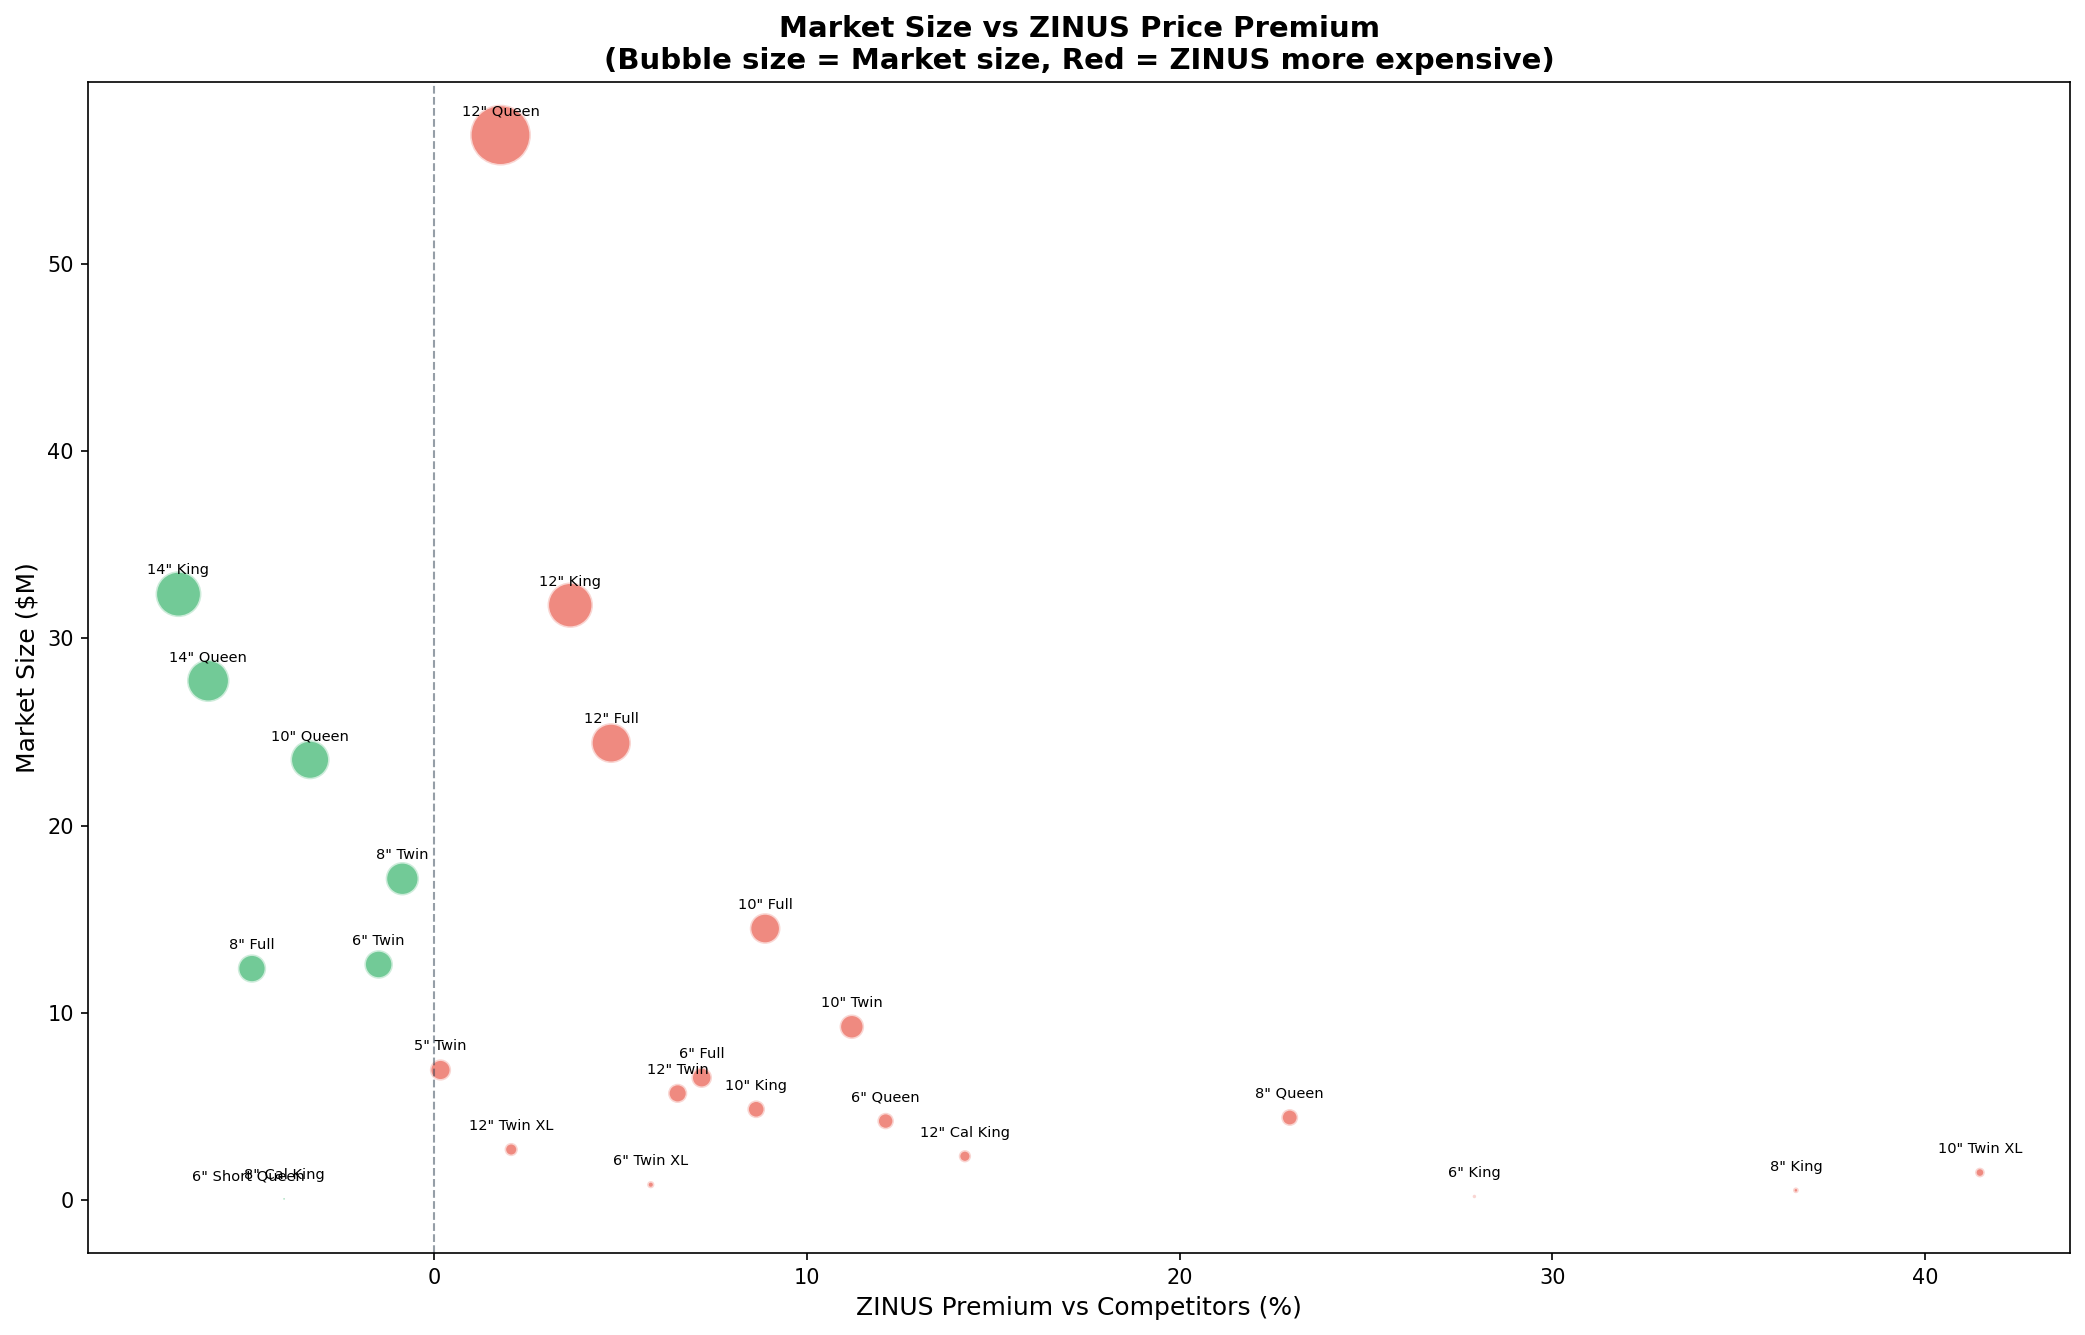


✅ 버블 차트 저장: risk_bubble_chart.png


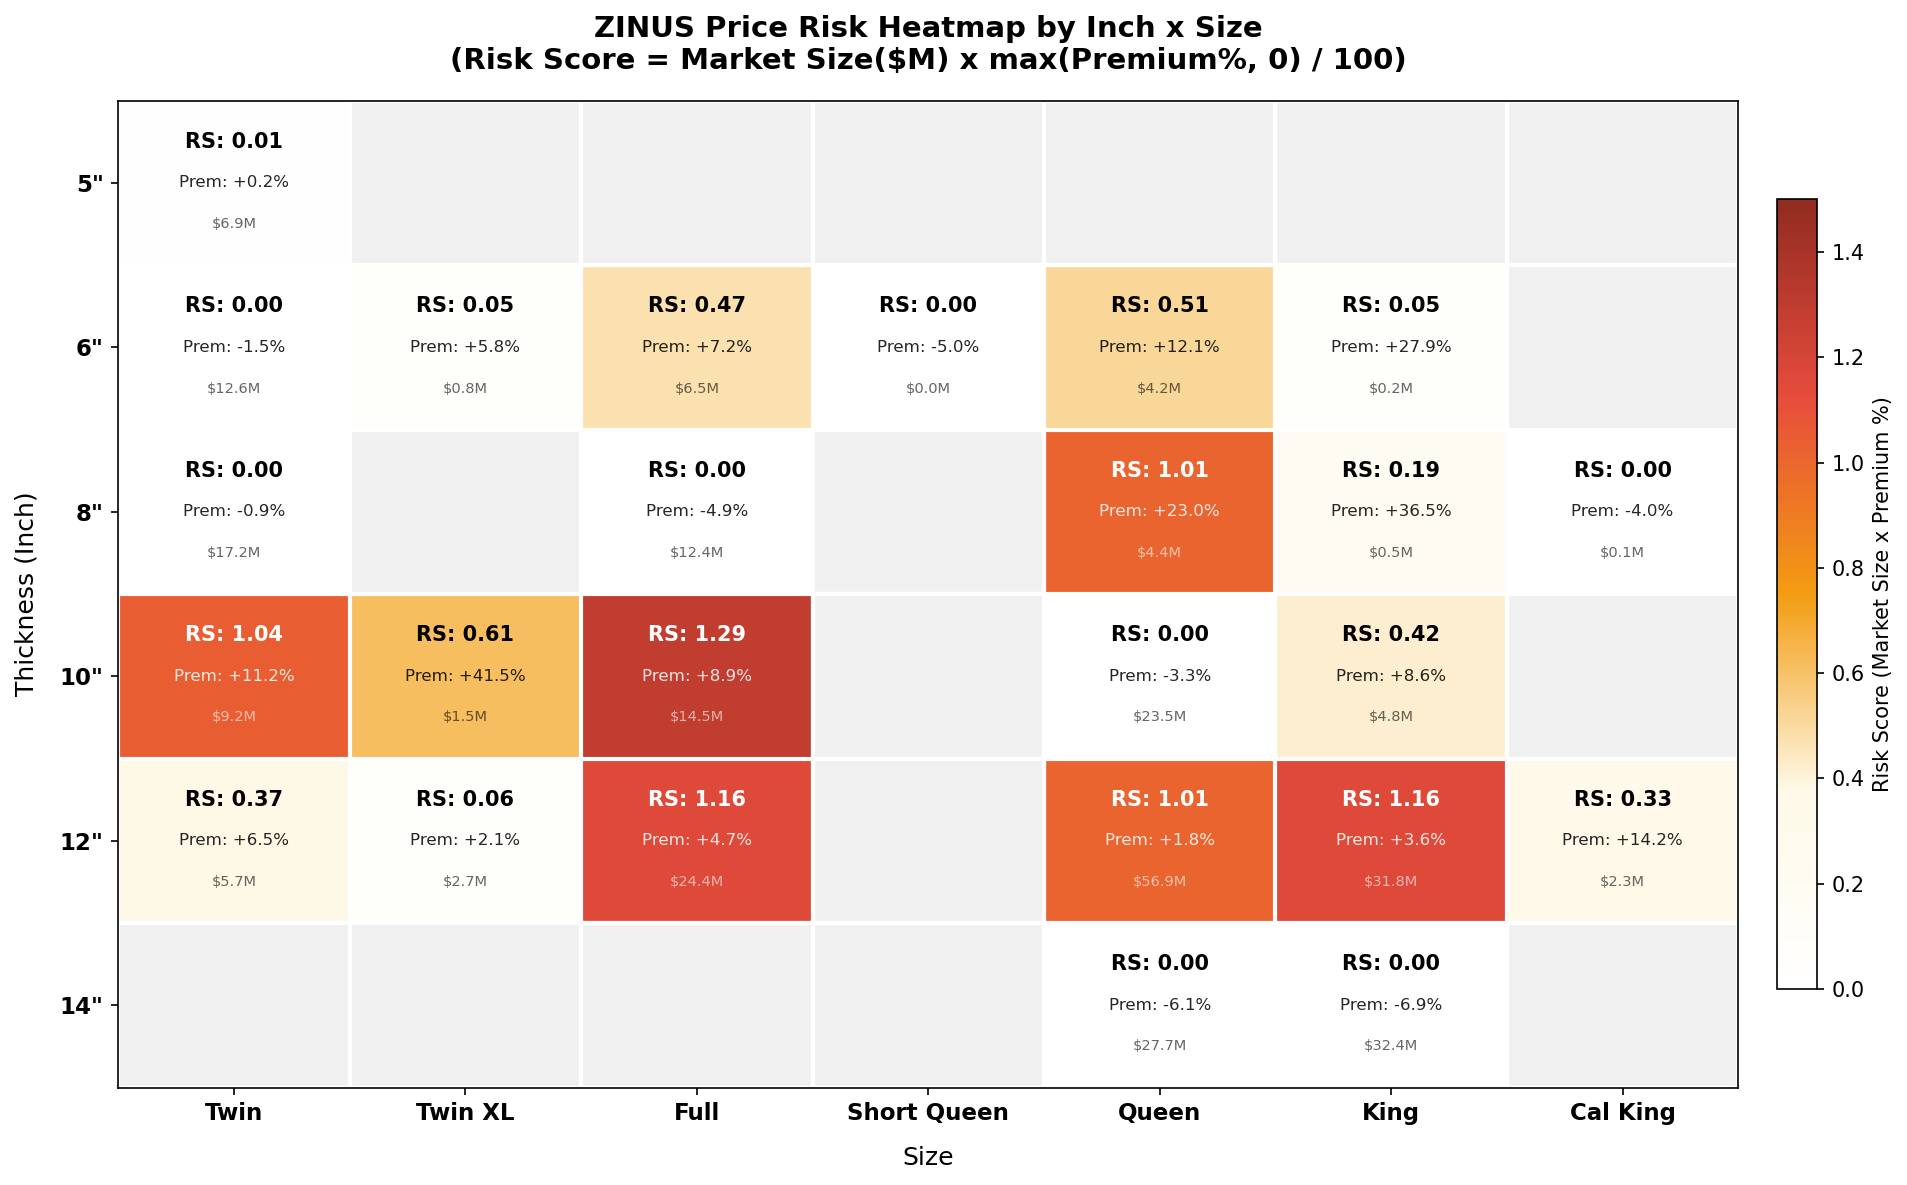

✅ Risk Score 히트맵 저장: risk_score_heatmap.png


In [55]:

mkt = pd.read_csv('amz_ms_inch_size_0322.csv')
mkt['inch'] = pd.to_numeric(mkt['inch'], errors='coerce')

# ─── 시장 규모 데이터 정리 ────────────────────────────────
mkt_clean = mkt.dropna(subset=['inch']).copy()
mkt_clean['sales_M'] = (mkt_clean['sales'] / 1e6).round(2)
mkt_clean['units_K'] = (mkt_clean['units'] / 1000).round(1)

total_sales = mkt_clean['sales'].sum()
mkt_clean['share_%'] = (mkt_clean['sales'] / total_sales * 100).round(1)

# ─── seg_premium과 결합 ──────────────────────────────────
# seg_premium의 inch, size와 mkt의 inch, size를 조인
risk = seg_premium.merge(
    mkt_clean[['inch', 'size', 'sales_M', 'units_K', 'share_%']],
    on=['inch', 'size'],
    how='left'
)

# 시장 규모 없는 세그먼트는 0으로 처리
risk['sales_M'] = risk['sales_M'].fillna(0)
risk['units_K'] = risk['units_K'].fillna(0)
risk['share_%'] = risk['share_%'].fillna(0)

# ─── Risk Score 계산 ──────────────────────────────────────
# Risk Score = 시장규모($M) × max(프리미엄%, 0) / 100
# 프리미엄이 음수(ZINUS가 저렴)인 세그먼트는 위험이 아니므로 0 처리
risk['risk_score'] = (risk['sales_M'] * risk['premium_%'].clip(lower=0) / 100).round(2)

# 정렬 및 출력
risk_sorted = risk.sort_values('risk_score', ascending=False)

print("=" * 80)
print("시장 규모 x ZINUS 프리미엄 결합 분석 (Risk Score)")
print("=" * 80)
print(risk_sorted[['inch', 'size', 'sales_M', 'share_%', 'premium_%', 'premium_$',
                    'zinus_n', 'zinus_asins', 'comp_asins', 'risk_score']].round(2).to_string(index=False))

# 위험 세그먼트만
print("\n" + "=" * 80)
print("Risk Score Top 10 (ZINUS가 비싼 세그먼트만)")
print("=" * 80)
risk_top = risk_sorted[risk_sorted['premium_%'] > 0].head(10)
print(risk_top[['inch', 'size', 'sales_M', 'share_%', 'premium_%', 'risk_score']].round(2).to_string(index=False))

# 안전 세그먼트 (ZINUS가 저렴 + 시장 규모 큰 순)
print("\n" + "=" * 80)
print("안전 세그먼트 (ZINUS가 저렴한 세그먼트, 시장규모 순)")
print("=" * 80)
risk_safe = risk[risk['premium_%'] < 0].sort_values('sales_M', ascending=False)
print(risk_safe[['inch', 'size', 'sales_M', 'share_%', 'premium_%']].round(2).to_string(index=False))

# ─── 시각화 1: 버블 차트 (시장규모 vs 프리미엄) ───────────
fig, ax = plt.subplots(figsize=(14, 9))

bubble_sizes = risk['sales_M'] * 15  # 버블 크기 조정
colors_list = ['#e74c3c' if p > 0 else '#27ae60' for p in risk['premium_%']]

scatter = ax.scatter(risk['premium_%'], risk['sales_M'],
                     s=bubble_sizes, c=colors_list, alpha=0.65, edgecolors='white', lw=1.5)

# 라벨 표시
for _, row in risk.iterrows():
    label = f"{row['inch']:.0f}\" {row['size']}"
    ax.annotate(label, (row['premium_%'], row['sales_M']),
                fontsize=7, ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')

ax.axvline(0, color='#2c3e50', ls='--', lw=1, alpha=0.5)
ax.set_xlabel('ZINUS Premium vs Competitors (%)', fontsize=12)
ax.set_ylabel('Market Size ($M)', fontsize=12)
ax.set_title('Market Size vs ZINUS Price Premium\n(Bubble size = Market size, Red = ZINUS more expensive)',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('risk_bubble_chart.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()
print("\n✅ 버블 차트 저장: risk_bubble_chart.png")

# ─── 시각화 2: Risk Score 히트맵 ──────────────────────────
size_order = ['Twin', 'Twin XL', 'Full', 'Short Queen', 'Queen', 'King', 'Cal King']

pivot_risk = risk.pivot_table(index='inch', columns='size', values='risk_score')
pivot_prem = risk.pivot_table(index='inch', columns='size', values='premium_%')
pivot_mkt  = risk.pivot_table(index='inch', columns='size', values='sales_M')

col_order = [s for s in size_order if s in pivot_risk.columns]
pivot_risk = pivot_risk[col_order]
pivot_prem = pivot_prem.reindex(columns=col_order)
pivot_mkt  = pivot_mkt.reindex(columns=col_order)

fig2, ax2 = plt.subplots(figsize=(14, 8))

cmap = mcolors.LinearSegmentedColormap.from_list(
    'risk', ['#ffffff', '#FEF9E7', '#F39C12', '#E74C3C', '#922B21']
)
vmax = max(pivot_risk.max().max(), 1.5)

im = ax2.imshow(pivot_risk.values, cmap=cmap, aspect='auto', vmin=0, vmax=vmax)

ax2.set_xticks(np.arange(len(pivot_risk.columns)))
ax2.set_xticklabels(pivot_risk.columns, fontsize=11, fontweight='bold')
ax2.set_yticks(np.arange(len(pivot_risk.index)))
ax2.set_yticklabels([f'{v:.0f}"' for v in pivot_risk.index], fontsize=11, fontweight='bold')

for i in range(len(pivot_risk.index)):
    for j in range(len(pivot_risk.columns)):
        rs = pivot_risk.iloc[i, j]
        if np.isnan(rs):
            ax2.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                         facecolor='#f0f0f0', edgecolor='white', lw=2))
            continue

        prem = pivot_prem.iloc[i, j]
        mkt_val = pivot_mkt.iloc[i, j]
        txt_color = 'white' if rs > 0.8 else 'black'

        # 1행: Risk Score
        ax2.text(j, i - 0.25, f'RS: {rs:.2f}',
                 ha='center', va='center', fontsize=10, fontweight='bold',
                 color=txt_color)
        # 2행: 프리미엄
        ax2.text(j, i + 0.0, f'Prem: {prem:+.1f}%',
                 ha='center', va='center', fontsize=8,
                 color=txt_color, alpha=0.85)
        # 3행: 시장 규모
        ax2.text(j, i + 0.25, f'${mkt_val:.1f}M',
                 ha='center', va='center', fontsize=7,
                 color=txt_color, alpha=0.6)

for i in range(len(pivot_risk.index) + 1):
    ax2.axhline(i - 0.5, color='white', lw=2)
for j in range(len(pivot_risk.columns) + 1):
    ax2.axvline(j - 0.5, color='white', lw=2)

cbar = plt.colorbar(im, ax=ax2, shrink=0.8, pad=0.02)
cbar.set_label('Risk Score (Market Size x Premium %)', fontsize=10)

ax2.set_title('ZINUS Price Risk Heatmap by Inch x Size\n'
              '(Risk Score = Market Size($M) x max(Premium%, 0) / 100)',
              fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Size', fontsize=12, labelpad=10)
ax2.set_ylabel('Thickness (Inch)', fontsize=12, labelpad=10)

plt.tight_layout()
plt.savefig('risk_score_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()
print("✅ Risk Score 히트맵 저장: risk_score_heatmap.png")